# 📂 Input Data
> Acquisition and configuration: dependencies, authentication, study area, and bitemporal image selection.

## Section 1 — Setup and Installation: Installs required dependencies and imports project modules

In [ ]:
#@title 1.1 — Install Dependencies {display-mode: "form"}
#@markdown Installs packages with tested versions
!pip install localtileserver==0.10.7 geemap==0.37.2 eemont==2025.7.1 spyndex \
  geopandas==1.1.2 rasterio==1.5.0 folium==0.20.0 pycrs==1.0.2 fiona==1.10.1 -q

#Old version geemap==0.36.5 (broken)

# Deep Learning (if not in Colab)
!pip install torch torchvision -q

print("✅ Dependencies installed")

import os, sys, importlib

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.7/33.7 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.6/184.6 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.7/341.7 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.4/771.4 kB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.4/281.4 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 119.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.5/287.5 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.3/204.3 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 128.4 MB/s eta 0:00:00
✅

In [ ]:
#@title 1.2 — Configure Project Path {display-mode: "form"}
#@markdown
#@markdown Enter below the **path to your root folder** in Google Drive.
#@markdown This folder must contain the subfolders `modulos/`, `Data/`, and the file
#@markdown `.kmz` of the study area.
#@markdown > **How to find the path:** In the left panel of Colab, click
#@markdown on 📁 *Files* → *Drive* and navigate to the project folder. Right-click
#@markdown the folder and select *Copy path*. Paste below.
#@markdown
#@markdown > Avoid special characters (accents, spaces) in folder names.
#@markdown Cole abaixo o caminho completo da pasta raiz do projeto no Google Drive:
#@markdown
#@markdown ---

# Definir caminho do projeto (ajuste conforme sua estrutura)
PROJECT_DIR = '/content/drive/MyDrive/Framework/Sobral_Perimeter'  # @param {type:"string"}
import sys
sys.path.insert(0, PROJECT_DIR)

# Import all modules
from modulos import config
from modulos.gee_setup import authenticate_gee, mount_drive, get_utm_crs
from modulos.image_processing import (
    create_tenst_config, create_bitemporal_config, create_configs_from_ids,
    search_available_images, create_preview_map,
    process_landsat_image, process_sentinel2_image, get_selected_landsat_image, get_selected_sentinel2_image
)
from modulos.lst_analysis import *
from modulos.downscaling import *
from modulos.spectral_analysis import *
from modulos.visualization import *
from modulos.export_utils import *
from modulos.zonal_analysis import *
from modulos.change_detection import run_inference, read_tif, write_tif
from modulos.water_mask import create_combined_water_mask_map

import ee
import re
import geemap
import numpy as np
import warnings
import eemont
warnings.filterwarnings('ignore')

print("✅ Modules imported successfully")


✅ Modules imported successfully


In [ ]:
#@title 1.3 — Authenticate Google Earth Engine {display-mode: "form"}
#@markdown
#@markdown To use Earth Engine, you need a **GEE project** (free for academic and research use).
#@markdown
#@markdown **How to find your project ID:**
#@markdown 1. Go to [code.earthengine.google.com](https://code.earthengine.google.com) with your Google account
#@markdown 2. In the top-left corner, see the active project name (e.g., `ee-yourname`)
#@markdown 3. Copy that name and paste it in the fieldpo abaixo
#@markdown
#@markdown **Don't have a GEE project yet?**
#@markdown - Go to [earthengine.google.com/signup](https://earthengine.google.com/signup/) and sign up (approval takes a few minutes for academic accounts)
#@markdown
#@markdown > After running the cell below, an authentication link will open in the browser. Log in with your Google account and paste the generated code into the box that appears.
#@markdown
#@markdown ---

project_id = "ee-joaovictornh01"  # @param {type:"string"}
authenticate_gee(project_id)


✓ Earth Engine already authenticated


In [ ]:
#@title 🔄 Reload Modules {display-mode: "form"}
#@markdown
#@markdown Run this cell only if you have edited files in `modulos/`
#@markdown and want to reload the modules without restarting the runtime.
#@markdown


import importlib
import modulos.config
import modulos.gee_setup
import modulos.image_processing
import modulos.lst_analysis
import modulos.downscaling
import modulos.spectral_analysis
import modulos.visualization
import modulos.export_utils
import modulos.zonal_analysis
import modulos.water_mask

_modules_to_reload = [
    modulos.config,
    modulos.gee_setup,
    modulos.image_processing,
    modulos.lst_analysis,
    modulos.downscaling,
    modulos.spectral_analysis,
    modulos.visualization,
    modulos.export_utils,
    modulos.zonal_analysis,
    modulos.water_mask,
]

for _mod in _modules_to_reload:
    importlib.reload(_mod)

# Re-import symbols to the notebook namespace
from modulos.gee_setup import authenticate_gee, mount_drive, get_utm_crs
from modulos.image_processing import (
    create_tenst_config, create_bitemporal_config, create_configs_from_ids,
    search_available_images, create_preview_map,
    process_landsat_image, process_sentinel2_image,
    get_selected_landsat_image, get_selected_sentinel2_image
)
from modulos.lst_analysis import *
from modulos.downscaling import *
from modulos.spectral_analysis import *
from modulos.visualization import *
from modulos.export_utils import *
from modulos.zonal_analysis import *
from modulos.water_mask import create_combined_water_mask_map

print("\n✅ All modules reloaded successfully!")



✅ All modules reloaded successfully!


## Section 2 — Define Region of Interest (ROI)

Define the geometry of your study area. Two options available:
| Option | When to use |
|---|---|
| **Import KML** | You already have a saved `.kml` file — provide the path and the ROI will be loaded automatically |
| **Draw and Save KML** | Draw the ROI on the interactive map and save as `.kml` for future reuse without redrawing |

In [ ]:
#@title 2.1 — Define ROI {display-mode: "form"}
#@markdown **Choose the mode and fill only the corresponding fields.**
#@markdown
#@markdown - `Import KML` → provide the path to the KML file
#@markdown - `Draw and Save KML` → draw on the map and run cell 2.2 to savefrom modulos.zonal_analysis import kml_to_ee_fixed

# ─── GENERAL CONFIGURATION ───────────────────────────────────────────────────
modo     = 'Import KML'  # @param ["Import KML", "Draw and Save KML"]
roi_name = 'A_Zone'        # @param {type: "string"}
zoom_map = 13              # @param {type:"number"}

# ─── OPTION 1 — IMPORT KML ────────────────────────────────────────────────────
# Only fill in if mode = "Import KML"
caminho_kml = '/content/drive/MyDrive/Framework/Sobral_Perimeter/Sobral_Perimeter.kml'  # @param {type:"string"}

# ─── OPTION 2 — DRAW AND SAVE KML ─────────────────────────────────────────────
# Fill only if mode = "Draw and Save KML"
caminho_salvar_kml  = '/content/drive/MyDrive/Framework/Sobral_Perimeter/'  # @param {type:"string"}
latitude_centro     = -3.69   # @param {type:"number"}
longitude_centro    = -40.35  # @param {type:"number"}

# ──────────────────────────────────────────────────────────────────────────────
Map = geemap.Map()
Map.add_basemap('SATELLITE')
if modo == 'Import KML':
  print(f"📂 Loading KML: {caminho_kml}")
  roi_fc = kml_to_ee_fixed(caminho_kml)
  roi    = roi_fc.geometry()
  Map.centerObject(roi, zoom_map)
  Map.addLayer(roi, {'color': 'yellow'}, f'ROI — {roi_name}')
  print(f"\n✅ ROI '{roi_name}' successfully loaded!")

elif modo == 'Draw and Save KML':
  Map.setCenter(longitude_centro, latitude_centro, zoom_map)
  print("✏️  Mode: Draw and Save KML")
  print()
  print("   1. Use the drawing tools in the upper left corner of the map.")
  print("   2. After drawing, run cell 2.2 to save the KML and set the ROI.")
  print(f"\n   KML will be saved at:\n   {caminho_salvar_kml}")

Map

📂 Loading KML: /content/drive/MyDrive/Framework/Sobral_Perimeter/Sobral_Perimeter.kml
✓ KML imported successfully!
  Number of features: 1
  Type: FeatureCollection

✅ ROI 'A_Zone' successfully loaded!


Map(center=[-3.680435678317549, -40.35398519959459], controls=(WidgetControl(options=['position', 'transparent…

In [ ]:
#@title 2.2 — Save Drawn ROI and Register in Earth Engine {display-mode: "form"}
#@markdown Run this cell **only after drawing the ROI** on the map in cell 2.1 (mode `Draw and Save KML`).
#@markdown
#@markdown - Saves the drawn geometry as a `.kml` file in the folder specified in `caminho_salvar_kml`
#@markdown - Sets the `roi` variable for use in the next pipeline steps
#@markdown - **To reuse in the future:** select `Import KML` in cell 2.1 and provide the existing pathbido abaixo

import os
import geopandas as gpd
import ee

if modo == 'Import KML':
    print("ℹ️ ROI already defined in cell 2.1 (Import KML mode).")
    print(f"   roi_name = '{roi_name}'")

elif modo == 'Draw and Save KML':
    # ── Capturar geometria desenhada no mapa ──────────────────────────────────
    drawn = []
    if hasattr(Map, 'draw_features') and Map.draw_features:
        drawn = Map.draw_features
    elif hasattr(Map, 'draw_last_feature') and Map.draw_last_feature:
        drawn = [Map.draw_last_feature]
    elif hasattr(Map, 'draw_control') and hasattr(Map.draw_control, 'data') and Map.draw_control.data:
        drawn = [{'type': 'Feature', 'geometry': g, 'properties': {}} for g in Map.draw_control.data]

    if not drawn:
        print("⚠️ No geometry detected on the map.")
        print("   Go back to cell 2.1, draw the ROI with the drawing tools")
        print("   and run this cell again.")
    else:
        if len(drawn) > 1:
            print(f"   ℹ️  {len(drawn)} geometry/ies found — using the last one.")
        feature = drawn[-1]

        # ── Normalize: ee.Feature/ee.Geometry → dict GeoJSON puro ──────────
        # geemap can return ComputedObjects (ee.Feature/ee.Geometry) instead
        # of dicts; .getInfo() downloads the serializable GeoJSON representation.
        if hasattr(feature, 'getInfo'):
            feature = feature.getInfo()
        elif isinstance(feature, dict):
            geom = feature.get('geometry')
            if geom is not None and hasattr(geom, 'getInfo'):
                feature = {**feature, 'geometry': geom.getInfo()}

        # ── Build full path of the KML file ─────────────────────────
        # caminho_salvar_kml can be a directory (ends with /) or a file
        _base = caminho_salvar_kml.rstrip('/').rstrip('\\')
        if os.path.isdir(_base) or caminho_salvar_kml.endswith('/') or caminho_salvar_kml.endswith('\\'):
            kml_path = os.path.join(_base, f'{roi_name}.kml')
        elif not _base.lower().endswith('.kml'):
            kml_path = _base + '.kml'
        else:
            kml_path = _base

        os.makedirs(os.path.dirname(kml_path), exist_ok=True)

        # ── Save locally (mounted Google Drive) ──────────────────────────
        gdf = gpd.GeoDataFrame.from_features([feature], crs="EPSG:4326")
        gdf['Name'] = roi_name
        gdf.to_file(kml_path, driver='KML')
        print(f"✅ KML saved locally at:")
        print(f"   {kml_path}")

        # ── Load into Earth Engine using the existing function ────────────────
        roi_fc = kml_to_ee_fixed(kml_path)
        roi    = roi_fc.geometry()
        print(f"\n✅ ROI '{roi_name}' defined in Earth Engine!")

        # ── View on map ────────────────────────────────────────────────
        Map.addLayer(roi, {'color': 'yellow'}, f'ROI — {roi_name}')
        Map.centerObject(roi, zoom_map)

        print(f"\n💡 To reuse this ROI in the future:")
        print(f"   → In cell 2.1, select 'Import KML' and use the path:")
        print(f"     {kml_path}")


ℹ️ ROI already defined in cell 2.1 (Import KML mode).
   roi_name = 'A_Zone'


## Section 3 — Search and Selection of T1/T2 Images

💡 Tips for Selecting Images

- **Cloud cover:** Lower values = cleaner images, but fewer options. For the northeastern semi-arid, 1–10% is usually sufficient. For humid regions (Amazon, coast), use 10–30%.

- **Landsat + Sentinel-2 pairs:** Images from both satellites on the same day are rare. Look for images with close dates (less than 15 days apart) to minimize seasonal variations.

- **Search period:** Prefer dry periods (fewer clouds) and avoid rainy periods.

In [ ]:
#@title 3.1 — Search Images for T1 (Initial Period) {display-mode: "form"}
#@markdown Define the time interval for the **reference period (before changes)**:

t1_start = '2019-06-01'  #@param {type:"date"}
t1_end = '2019-12-31'  #@param {type:"date"}

#@markdown ---
#@markdown **Landsat satellite:**
landsat_type = 'L8'  #@param ["L8", "L9"]
#@markdown *(Landsat 8 — available from 2013 today  ·  Landsat 9 — available from 2022)*

#@markdown ---
#@markdown **Maximum cloud cover (%)** — *Recommended: 1–10% for semi-arid; 10–30% for humid regions:*
cloud_cover_t1 = 1  #@param {type:"slider", min:0, max:50, step:1}

print('\n🔍 SEARCHING AVAILABLE IMAGES FOR T1...')
config_search_t1 = create_tenst_config(
    start_date=t1_start,
    end_date=t1_end,
    geometry=roi,
    landsat_type=landsat_type,
    cloud_cover=cloud_cover_t1,
)
search_available_images(config_search_t1);



🔍 SEARCHING AVAILABLE IMAGES FOR T1...
CONFIGURATION
Search period: 2019-06-01 to 2019-12-31
Satellite: Landsat L8
Maximum cloud cover: 1%
Coordinate system: EPSG:32724

SEARCHING AVAILABLE IMAGES: 2019-06-01 to 2019-12-31
ℹ️  Times converted to Brasília timezone (UTC-3)

🛰️  Searching Landsat L8...
   Images found: 4

   --- Landsat image IDs ---
   1. LC08_218063_20190810
      Date: 2019-08-10 | Time (Brasília): 09:53:06 | Clouds: 0.00%
   2. LC08_218063_20190927
      Date: 2019-09-27 | Time (Brasília): 09:53:19 | Clouds: 0.31%
   3. LC08_218063_20191013
      Date: 2019-10-13 | Time (Brasília): 09:53:22 | Clouds: 0.67%
   4. LC08_218063_20191029
      Date: 2019-10-29 | Time (Brasília): 09:53:23 | Clouds: 0.03%

🛰️  Searching Sentinel-2...
Using collection: COPERNICUS/S2_SR_HARMONIZED (Surface Reflectance)
   Images found: 4

   --- Sentinel-2 image IDs ---
   1. 20190810T131251_20190810T131246_T24MUA
      Date: 2019-08-10 | Time (Brasília): 10:13:18 | Clouds: 0.00%
   2. 201908

In [ ]:
#@title 3.2 — Select T1 Images {display-mode: "form"}
#@markdown Paste below the **IDs of the chosen images** from the table above.
#@markdown Copy the exact value from the `id` column (e.g., `LC08_218063_20190810`).
#@markdown If no suitable images were found, go back to the previous cell and increase cloud cover or expand the period.

selected_landsat_t1 = 'LC08_218063_20190810'  #@param {type:"string"}
selected_sentinel2_t1 = '20190810T131251_20190810T131246_T24MUB'  #@param {type:"string"}
print(f'✅ IDs selecionados para T1: Landsat={selected_landsat_t1}, S2={selected_sentinel2_t1}')

from modulos.visualization import visualize_selected_images

try:
    map_t1 = visualize_selected_images(
        l8_id=selected_landsat_t1,
        s2_id=selected_sentinel2_t1,
        roi=roi,
        zoom=zoom_map
    )
    display(map_t1)
except NameError:
    print('⚠️  Run Cell 2.1 (Define Study Area) first.')
except Exception as e:
    print(f'❌ Error creating visualization: {e}')


✅ IDs selecionados para T1: Landsat=LC08_218063_20190810, S2=20190810T131251_20190810T131246_T24MUB


Map(center=[-3.6804356819012, -40.35398519931084], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
#@title 3.3 — Search Images for T2 (Final Period) {display-mode: "form"}
#@markdown Define the time interval for the **final period (after changes)**:

t2_start = '2025-06-01'  #@param {type:"date"}
t2_end = '2025-12-31'  #@param {type:"date"}

#@markdown ---
#@markdown **Maximum cloud cover (%)** — *Use the same value as T1 for a fair comparison:*
cloud_cover_t2 = 1  #@param {type:"slider", min:0, max:50, step:1}

print('\n🔍 SEARCHING AVAILABLE IMAGES FOR T2...')
config_search_t2 = create_tenst_config(
    start_date=t2_start,
    end_date=t2_end,
    geometry=roi,
    landsat_type=landsat_type,
    cloud_cover=cloud_cover_t2,
)
search_available_images(config_search_t2);



🔍 SEARCHING AVAILABLE IMAGES FOR T2...
CONFIGURATION
Search period: 2025-06-01 to 2025-12-31
Satellite: Landsat L8
Maximum cloud cover: 1%
Coordinate system: EPSG:32724

SEARCHING AVAILABLE IMAGES: 2025-06-01 to 2025-12-31
ℹ️  Times converted to Brasília timezone (UTC-3)

🛰️  Searching Landsat L8...
   Images found: 3

   --- Landsat image IDs ---
   1. LC08_218062_20250927
      Date: 2025-09-27 | Time (Brasília): 09:52:49 | Clouds: 0.63%
   2. LC08_218063_20250927
      Date: 2025-09-27 | Time (Brasília): 09:53:13 | Clouds: 0.34%
   3. LC08_218063_20251029
      Date: 2025-10-29 | Time (Brasília): 09:53:16 | Clouds: 0.32%

🛰️  Searching Sentinel-2...
Using collection: COPERNICUS/S2_SR_HARMONIZED (Surface Reflectance)
   Images found: 4

   --- Sentinel-2 image IDs ---
   1. 20250818T131301_20250818T131301_T24MUB
      Date: 2025-08-18 | Time (Brasília): 10:13:19 | Clouds: 0.43%
   2. 20250917T131251_20250917T131254_T24MUA
      Date: 2025-09-17 | Time (Brasília): 10:13:27 | Clouds: 

In [ ]:
#@title 3.4 — Select T2 Images {display-mode: "form"}
#@markdown Paste below the **IDs of the chosen images** from the table above (column `id`):

selected_landsat_t2 = 'LC08_218062_20250927'  #@param {type:"string"}
selected_sentinel2_t2 = '20250927T131301_20250927T131257_T24MUA'  #@param {type:"string"}
print(f'✅ IDs selecionados para T2: Landsat={selected_landsat_t2}, S2={selected_sentinel2_t2}')

from modulos.visualization import visualize_selected_images

try:
    map_t2 = visualize_selected_images(
        l8_id=selected_landsat_t2,
        s2_id=selected_sentinel2_t2,
        roi=roi,
        zoom=zoom_map
    )
    display(map_t2)
except NameError:
    print('⚠️  Run Cell 2.1 (Define Study Area) first.')
except Exception as e:
    print(f'❌ Error creating visualization: {e}')


✅ IDs selecionados para T2: Landsat=LC08_218062_20250927, S2=20250927T131301_20250927T131257_T24MUA


Map(center=[-3.6804356819012, -40.35398519931084], controls=(WidgetControl(options=['position', 'transparent_b…

## Section 4 — Bitemporal Configuration: Creates the settings for bitemporal analysis with the selected IDs.

In [ ]:
#@title 4.0 — Generate Configuration {display-mode: "form"}

#@markdown - **Site name:** Use a name without spaces or accents (e.g., `North_Quarter_Sobral`). It will be used as a prefix in files exported to Google Drive.
#@markdown - **Cartographic projection (UTM):** Choose the UTM zone matching your city. Each zone covers a 6° longitude band. If unsure, use the closest option.
#@markdown - **Export folder:** Name of the folder on Google Drive where results will be saved. If the folder does not exist, Earth Engine will create it automatically.
#@markdown
#@markdown ---
#@markdown **Study site name** (no spaces or accents):
site_name = 'Sobral_Perimeter'  #@param {type:"string"}

#@markdown ---
#@markdown **Cartographic projection — UTM zone of your city:**
_crs_opcao = 'EPSG:32724 — UTM 24S (Ceará, RN, PE, BA north)'  #@param [
#   "EPSG:32718 — UTM 18S (Acre, Amazonas oeste)",
#   "EPSG:32719 — UTM 19S (Amazonas, Pará west)",
#   "EPSG:32720 — UTM 20S (Pará center, Mato Grosso north)",
#   "EPSG:32721 — UTM 21S (Mato Grosso, Mato Grosso do Sul, Goiás, Tocantins)",
#   "EPSG:32722 — UTM 22S (São Paulo interior, Paraná)",
#   "EPSG:32723 — UTM 23S (São Paulo, Rio de Janeiro, Minas Gerais, DF)",
#   "EPSG:32724 — UTM 24S (Ceará, Rio Grande do Norte, Pernambuco, Bahia north)",
#   "EPSG:32725 — UTM 25S (Nordeste extremo leste)"
# ]
export_crs = _crs_opcao.split(' — ')[0]  # extract the EPSG code only

#@markdown ---
#@markdown **Export folder name on Google Drive:**
export_folder = 'Data_Sobral_Perimeter'  #@param {type:"string"}

config_bitemporal, config_t1, config_t2 = create_configs_from_ids(
    roi=roi,
    t1_start_date=config_search_t1['start_date'],
    t1_end_date=config_search_t1['end_date'],
    t2_start_date=config_search_t2['start_date'],
    t2_end_date=config_search_t2['end_date'],
    landsat_type=landsat_type,
    cloud_cover=cloud_cover_t1,
    landsat_t1_id=selected_landsat_t1,
    sentinel2_t1_id=selected_sentinel2_t1,
    landsat_t2_id=selected_landsat_t2,
    sentinel2_t2_id=selected_sentinel2_t2,
    site_name=site_name,
    export_crs=export_crs,
    export_folder=export_folder,
)
print(f'✅ Settings generated | Site: {site_name} | CRS: {export_crs} | Folder: {export_folder}')


BITEMPORAL THERMAL ANALYSIS CONFIGURATION
T1 period: 2019-06-01 to 2019-12-31
  Landsat T1 ID: LC08_218063_20190810
  Sentinel-2 T1 ID: 20190810T131251_20190810T131246_T24MUB
T2 period: 2025-06-01 to 2025-12-31
  Landsat T2 ID: LC08_218062_20250927
  Sentinel-2 T2 ID: 20250927T131301_20250927T131257_T24MUA
Satellite: Landsat L8
Maximum cloud cover: 1%
Site: Sobral_Perimeter
Coordinate system: EPSG:32724
CONFIGURATION
Search period: 2019-06-01 to 2019-12-31
Satellite: Landsat L8
Maximum cloud cover: 1%
Selected Landsat ID: LC08_218063_20190810
Selected Sentinel-2 ID: 20190810T131251_20190810T131246_T24MUB
Coordinate system: EPSG:32724
CONFIGURATION
Search period: 2025-06-01 to 2025-12-31
Satellite: Landsat L8
Maximum cloud cover: 1%
Selected Landsat ID: LC08_218062_20250927
Selected Sentinel-2 ID: 20250927T131301_20250927T131257_T24MUA
Coordinate system: EPSG:32724
✅ Settings generated | Site: Sobral_Perimeter | CRS: EPSG:32724 | Folder: Data_Sobral_Perimeter


# ⚙️ Processing Tasks> Processing tasks for generating data on Land Surface Temperature (LST); Surface Urban Heat Island (SUHI); Binary change detection map; Spectral Index.

## Section 5 — Compute LST and SUHI at Original Resolution (30 m)

Computes Landsat Land Surface Temperature (LST) for T1 and T2,
keeping the original **30-meter** resolution. Sufficient to identify
neighborhoods and urban heat zones in the study area.
> **Urban planning**: With LST it is possible to identify **surface heat islands**,
> compare temperatures between T1 and T2, and cross-reference with the change map to understand
> o impacto do crescimento urbano no microclima local.


In [ ]:
# @title 5.1 — Run to Compute Bitemporal LST and SUHI {display-mode: "form"}
# @markdown
# @markdown **Prerequisite:** cell 4.0 must be run first.

import io, contextlib

_wm_t1 = globals().get('water_mask_t1')
_wm_t2 = globals().get('water_mask_t2')

methods = []   # Sem downscaling — utiliza a LST 30m original do Landsat

print('🔄 Calculating 30m LST (original Landsat)...')

with contextlib.redirect_stdout(io.StringIO()):
    results_bitemporal = calculate_bitemporal_lst(
        config_t1,
        config_t2,
        s2_collection_t1='COPERNICUS/S2_SR_HARMONIZED',
        s2_collection_t2='COPERNICUS/S2_SR_HARMONIZED',
        methods=methods,
        water_mask_t1=_wm_t1,
        water_mask_t2=_wm_t2,
    )
    stats_change = calculate_thermal_change_statistics(
        results_bitemporal,
        roi,
        methods=methods
    )

print('✅ Bitemporal processing completed!')
print('✅ 30m LST calculated for T1 and T2!')

🔄 Calculating 30m LST (original Landsat)...
✅ Bitemporal processing completed!
✅ 30m LST calculated for T1 and T2!


## Section 6 — Urban Change Detection with Artificial Intelligence

> ⚠️ **This section requires a GPU.**> In Google Colab: `Runtime → Change runtime type → GPU T4`

This step uses the **neural network** (Siamese U-Net) proposed by:`Hafner, S., Ban, Y. and Nascetti, A., 2023. Semi-Supervised Urban Change Detection Using Multi-Modal Sentinel-1 SAR and Sentinel-2 MSI Data. Remote Sensing, 15(21), p.5135.`

The authors made the model with its weights available on [Github](https://github.com/SebastianHafner/SemiSupervisedMultiModalCD). The neural network was trained to compare Sentinel-2 images from T1 and T2 and identify, pixel by pixel, where **new buildings** appeared between the two periods.

The result is a **change probability** map (0–100) for the entire study area, which will be converted to a binary map (change / no change) in Section 8.

> - You do not need to know the technical details of the model to run this notebook, but for more information see [Github](https://github.com/SebastianHafner/SemiSupervisedMultiModalCD).

> - Basta configurar os caminhos das imagens (exportadas na etapa 6.1) e executar.

In [ ]:
# @title 6.0 — Prerequisite to Proceed to Section 6 {display-mode: "form"}
# @markdown >Export Images for Change Detection
# @markdown
# @markdown Exports Sentinel-2 and Sentinel-1 images as GeoTIFF to Google Drive
# @markdown so they can be loaded into the neural network in Section 6.
# @markdown
# @markdown ---
# @markdown Note: If you have already exported the images and only want to reloadgar
# @markdown the images, select the option "No"
# @markdown
# @markdown ---

Export  = 'Yes'  # @param ['Yes', 'No']
if Export == 'Yes':
    tasks = export_bitemporal_results(
        results_bitemporal,
        config_bitemporal,
        config_t1['geometry'],
        # Disable everything except S2 and S1
        export_lst_30m=False,
        export_lst_10m=False,
        export_uhi_30m=False,
        export_uhi_10m=False,
        export_uhi_intensity_30m=False,
        export_uhi_intensity_10m=False,
        export_landsat_indices=False,
        export_sentinel2_indices=False,
        # Only S2 and S1
        export_sentinel2=True,
        export_sentinel1=True,
        sentinel2_bands=['B2', 'B3', 'B4', 'B8', 'B11', 'B12']
    )

    print(f"\n✅ Export complete!")
    print(f"Monitor progress on: https://code.earthengine.google.com/tasks")

elif Export != 'Yes':
    print(f"\n❌ Export cancelled.")


EXPORTING SELECTED PRODUCTS TO GOOGLE DRIVE
Determined CRS: EPSG:32724

📋 EXPORT SUMMARY:
  • LST 30m (Landsat): NO
  • LST 10m (Downscaled): NO
  • UHI 30m (Normalized): NO
  • UHI 10m (Normalized): NO
  • UHI Intensity Classification 30m (Deng et al. 2023): NO
  • UHI Intensity Classification 10m (Deng et al. 2023): NO
  • Landsat Indices (30m): NO
  • Landsat SR Imagery (30m): NO
  • Delta LST 30m T2-T1: NO
  • Delta LST 10m T2-T1: NO
  • Delta Landsat Indices T2-T1 (30m): NO
  • Delta Sentinel-2 Indices T2-T1 (10m): NO
  • Delta UHI 30m T2-T1: NO
  • Delta UHI Intensity 30m T2-T1: NO
  • Delta UHI 10m T2-T1: NO
  • Delta UHI Intensity 10m T2-T1: NO
  • CDI Landsat (dLST_30m x dIndex, 30m): NO
  • CDI Sentinel-2 (dLST_30m x dIndex, 10m): NO

EXPORTING SENTINEL-2
  Bands (Custom): ['B2', 'B3', 'B4', 'B8', 'B11', 'B12']

📊 Exporting Sentinel-2 T1...
  ✓ Sentinel-2 T1 started
📊 Exporting Sentinel-2 T2...
  ✓ Sentinel-2 T2 started

EXPORTING SENTINEL-1 SAR

📡 Exporting Sentinel-1 T1...

Wait for Image Export. The images have been sent for processing in Google Earth Engine. Wait time varies with study area size (5–30 minutes).
**How to check if the export finished:**
1. Go to [code.earthengine.google.com/tasks](https://code.earthengine.google.com/tasks)
2. Wait for the status to change from ⏳ *Running* to ✅ *Completed*
3. Confirm that the filesos apareceram na pasta `Data/` no seu Google Drive
> ⚠️ **Only continue after confirming that the files have been saved.** The larger the ROI area, the longer the export will take.

AI Model Path Configuration

Enter below where:
- **Exported images folder** (generated in Section 5) — must end with `/`
- **Model folder** — contains the `.pt` file of the neural network
- **ROI name** — must be exactly equal to the `site_name` defined in Section 4

> 💡 **Tip:** You can copy the folder path directly from the Colab *Files* panel (right-click the folder → *Copy path*).

In [ ]:
#@title 6.1 — AI Model Path Configuration {display-mode: "form"}

#@markdown Enter below where:
#@markdown - **Exported images folder** (cell 6.0) — must end with `/`
#@markdown - **Model folder** — contains the `.pt` file of the neural network
#@markdown - **ROI name** — must be exactly equal to the `site_name` defined in Section 4
#@markdown
#@markdown > **Tip:** You can copy the folder path directly from the Colab *Files* panel (right-click the folder → *Copy path*).
#@markdown
#@markdown ---

#@markdown **Exported images folder** (must end with `/`):
folder_imgs = "/content/drive/MyDrive/Framework/Sobral_Perimeter/Data_Sobral_Perimeter/"  #@param {type:"string"}

#@markdown **AI model folder** (must end with `/`):
folder_model = "/content/drive/MyDrive/Framework/Heigths_Neural_Network_Change_Detection/"  #@param {type:"string"}

#@markdown **Model file name** (without `.pt` extension):
model_name = 'mmcr_train100'  #@param {type:"string"}

#@markdown **ROI name** (same as `site_name` from Section 4):
cd_roi_name = 'Sobral_Perimeter'  #@param {type:"string"}

# Validar caminhos antes de prosseguir
import os
_model_file = os.path.join(folder_model, model_name + '.pt')

if not os.path.isdir(folder_imgs):
    print(f'❌ Images folder not found: {folder_imgs}')
    print('   Check the path and confirm that the Section 6 export is complete.')
elif not os.path.isfile(_model_file):
    print(f'❌ Model "{model_name}.pt" not found in: {folder_model}')
    print('   Check the model name and folder path.')
else:
    print('✅ Paths checked!')
    print(f'   📂 Images: {folder_imgs}')
    print(f'   🧠 Model: {_model_file}')
    print(f'   🗺️  ROI: {cd_roi_name}')


✅ Paths checked!
   📂 Images: /content/drive/MyDrive/Framework/Sobral_Perimeter/Data_Sobral_Perimeter/
   🧠 Model: /content/drive/MyDrive/Framework/Heigths_Neural_Network_Change_Detection/mmcr_train100.pt
   🗺️  ROI: Sobral_Perimeter


🔧 GPU available: True
🔧 GPU: Tesla T4

🧠 CHANGE DETECTION - INFERENCE WITH SIAMESE U-NET
📱 Device: cuda

📥 Loading model...
✔ Model loaded: /content/drive/MyDrive/Framework/Heigths_Neural_Network_Change_Detection/mmcr_train100.pt

📂 Loading satellite data...
✔ Files loaded successfully!
  - S1 T1: /content/drive/MyDrive/Framework/Sobral_Perimeter/Data_Sobral_Perimeter/sentinel1_Sobral_Perimeter_t1.tif | shape: (1099, 1012, 2)
  - S1 T2: /content/drive/MyDrive/Framework/Sobral_Perimeter/Data_Sobral_Perimeter/sentinel1_Sobral_Perimeter_t2.tif | shape: (1099, 1012, 2)
  - S2 T1: /content/drive/MyDrive/Framework/Sobral_Perimeter/Data_Sobral_Perimeter/sentinel2_Sobral_Perimeter_t1.tif | shape: (1099, 1012, 6)
  - S2 T2: /content/drive/MyDrive/Framework/Sobral_Perimeter/Data_Sobral_Perimeter/sentinel2_Sobral_Perimeter_t2.tif | shape: (1099, 1012, 6)

🔍 Input value diagnostics:
  S1 T1 — min: 0.0000, max: 1.0000, mean: 0.4738
  S1 T2 — min: 0.0000, max: 1.0000, mean: 0.4677
  S2 T1 — min: 0.0

Processing tiles:   0%|          | 0/72 [00:00<?, ?it/s]

✔ Inference completed!

✂️ Removing padding to original dimensions...
  - Final dimensions: (1099, 1012, 3)
  - Coverage: 100% of original pixels processed! ✅

📊 Prediction statistics:
  - Change map     — Min: 0, Max: 100, Mean: 1.60
  - Segmentation T1 — Min: 0, Max: 100, Mean: 4.63
  - Segmentation T2 — Min: 0, Max: 100, Mean: 6.13

💾 Saving results...
  ✔ Change map: /content/drive/MyDrive/Framework/Sobral_Perimeter/Data_Sobral_Perimeter/pred_Sobral_Perimeter.tif
  ✔ Segmentation T1: /content/drive/MyDrive/Framework/Sobral_Perimeter/Data_Sobral_Perimeter/seg_t1_Sobral_Perimeter.tif
  ✔ Segmentation T2: /content/drive/MyDrive/Framework/Sobral_Perimeter/Data_Sobral_Perimeter/seg_t2_Sobral_Perimeter.tif

✅ Change map saved successfully!


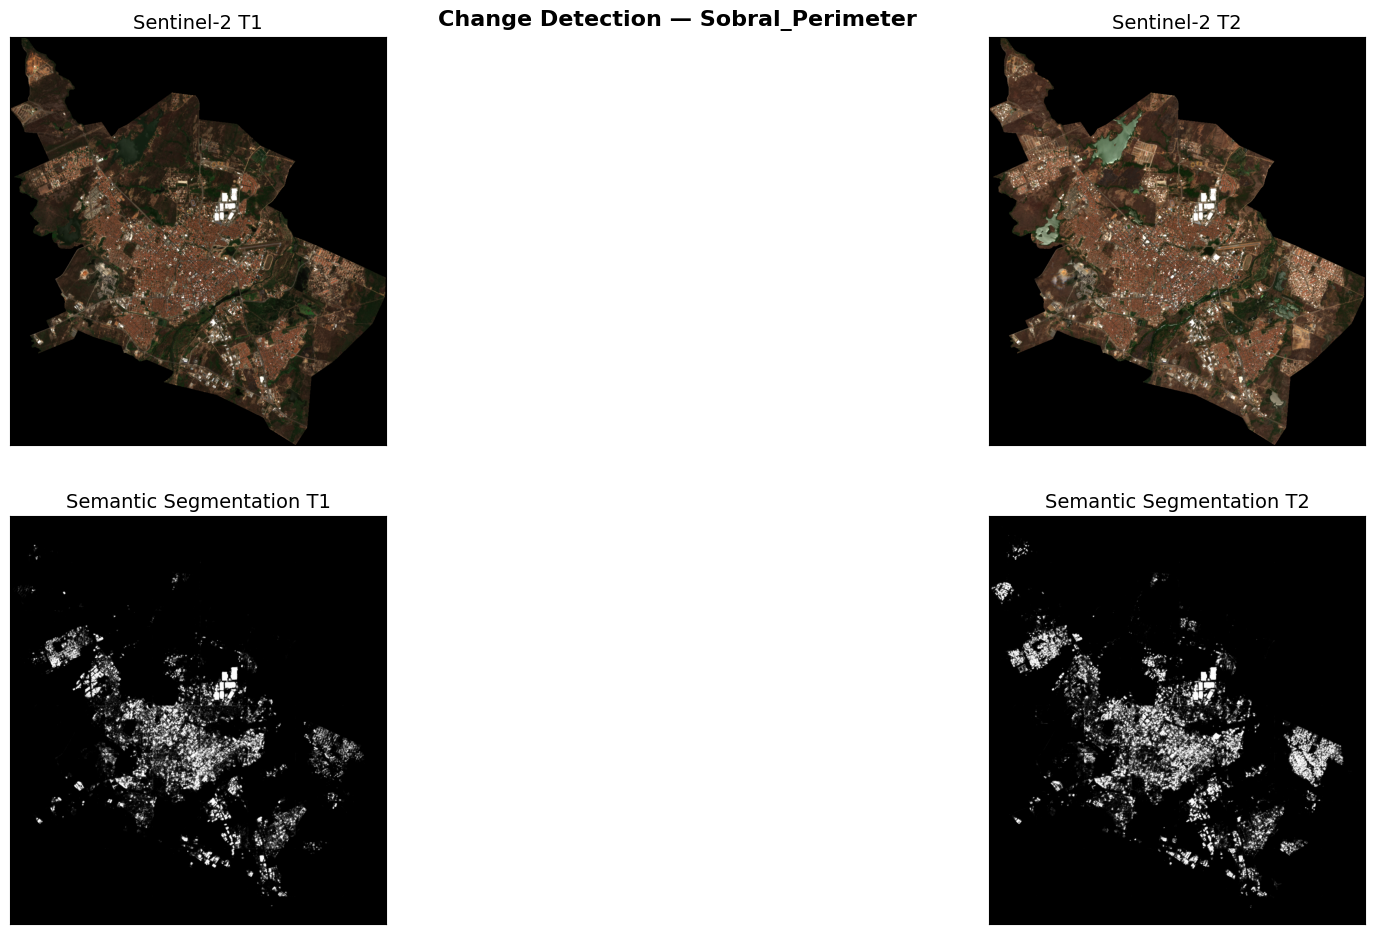

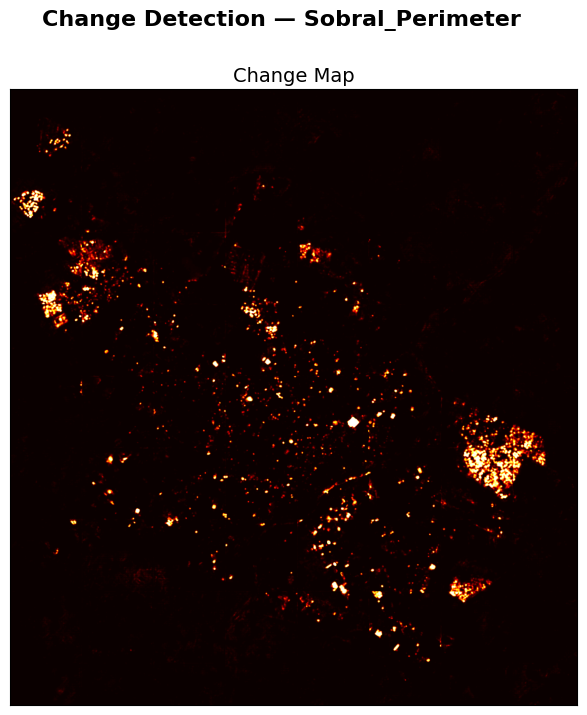


✅ Prediction saved at: /content/drive/MyDrive/Framework/Sobral_Perimeter/Data_Sobral_Perimeter/pred_Sobral_Perimeter.tif


In [ ]:
# @title 6.2 — Run Change Detection Model {display-mode: "form"}
# @markdown ⏱️ Estimated time: ~2-5 min (depends on scene size)
import torch
print(f"🔧 GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"🔧 GPU: {torch.cuda.get_device_name(0)}")

pred_file = run_inference(
    folder_imgs=folder_imgs,
    roi_name=cd_roi_name,
    folder_model=folder_model,
    model_name=model_name,
    tile_size=128
)

print(f"\n✅ Prediction saved at: {pred_file}")


**Before continuing:**
1. Wait for the cell above to finish
2. Confirm that the file `pred_<roi_name>.tif` appeared in the `Data/` folder on Google Drive
3. If a GPU error occurred, go to *Runtime → Change hardware type → GPU T4*

The AI model generates a **probability** map — each pixel has a value from 0 to 100indicating how "likely" that point is to have undergone urban change.

Here we convert that map to a simple binary answer:
- **Value 1** → urban change detected (new building)
- **Value 0** → no significant change (no new building)

This map will be integrated with thermal analyses to answer the question:
> **What is the surface thermal behavior of the areas that grew the most?**

In [ ]:
# @title 6.3 — Load the Probability Map {display-mode: "form"}
#@markdown
#@markdown Enter the full path of the file generated by the model in the previous step. The file has the prefix `pred_` followed by the ROI name (e.g., `pred_Renato_Parente_Loteamento.tif`).
#@markdown
#@markdown > 💡 You can copy the path by right-clicking the file in the Colab *Files* panel → *Copy path*.
#@markdown
#@markdown ---
pred_path = "/content/drive/MyDrive/Framework/Sobral_Perimeter/Data_Sobral_Perimeter/pred_Sobral_Perimeter.tif"  # @param {type: "string"}
prediction_data, pred_transform, pred_crs, nodata, bounds, shape = load_geotiff(pred_path)

print(f"✅ Model result loaded successfully!")


✅ Model result loaded successfully!



✓ Threshold applied: 45.00
   • Change pixels (≥45.00): 14,225 (1.28%)
   • No-change pixels (<45.00): 1,097,963 (98.72%)


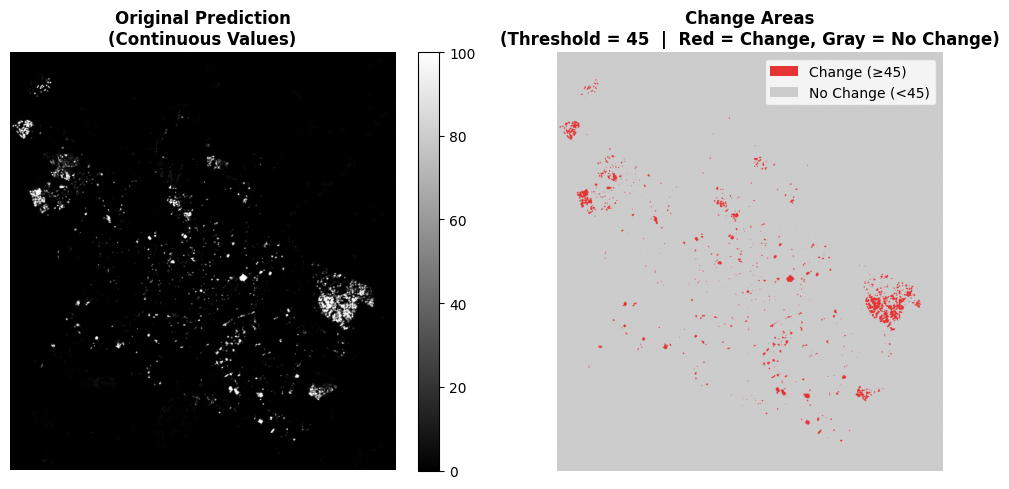


✅ Change map generated (threshold = 45)
   Area with detected change: 1.3% of the analyzed scene
   Pixels with change: 14,225 of 1,112,188 total

💡 The change area seems low. Consider reducing the threshold in Manual mode.


In [ ]:
# @title 6.4 — Convert Probability to Binary Change Map {display-mode: "form"}
# @markdown
# @markdown The U-Net model generated a **probability** map (0–100) for each pixel.
# @markdown Here we define the cutoff: pixels above the threshold → change detected.
# @markdown
# @markdown ---
# @markdown
# @markdown ## Threshold definition mode
modo_limiar = 'Manual'  # @param ['Automatic', 'Manual']
# @markdown > **Automatic** — uses the default threshold (45), validated in the Sobral study.
# @markdown
# @markdown > **Manual** — ajusta o valor manualmente.
# @markdown >
# @markdown > Note: *Higher threshold → less area detected as change (more conservative)*.
# @markdown > *Lower threshold → more area detected as change (more sensitive)*
# @markdown
# @markdown ---
threshold_manual = 45  # @param {type: "slider", min: 0, max: 100, step: 5}

threshold = 45 if modo_limiar == 'Automatic' else threshold_manual

binary_mask = apply_threshold(prediction_data, threshold, nodata_value=nodata)
visualize_binary_mask(binary_mask, prediction_data, threshold)

# Summary statistics
_n_mudanca = int(binary_mask.sum())
_n_total   = int((binary_mask >= 0).sum())
_pct = 100 * _n_mudanca / _n_total if _n_total > 0 else 0

print(f"\n✅ Change map generated (threshold = {threshold})")
print(f"   Area with detected change: {_pct:.1f}% of the analyzed scene")
print(f"   Pixels with change: {_n_mudanca:,} of {_n_total:,} total")

if _pct > 40:
    print("\n💡 The change area seems high. Consider increasing the threshold in Manual mode.")
elif _pct < 2:
    print("\n💡 The change area seems low. Consider reducing the threshold in Manual mode.")
else:
    print("\n   Run 8.3 to integrate this map with Google Earth Engine.")


---
# ✅ Pipeline Complete!

All results processed. Check:
- **Google Drive** — Products exported to the folder configured in Section 4
- **Local file** — `pred_{roi_name}.tif` with the change map